# Explore Bayesian Network

This is to explore the usage of Bayesian Network for modeling multivariate distribution of categorical variables as what we have.

In [1]:
from pgmpy.models.BayesianNetwork import BayesianNetwork
from pgmpy.factors.discrete.CPD import TabularCPD

### Step 1: Define Model Structure

Since BN structure learning is quite challenging and we don't have the real data for learing it from, we just assume the network structure based on some causal assumptions. Also, the network should satisfy the acyclicity assumption.

Graph structure looks like this:
```mermaid
    Graph TD:
        A --> E;
        A --> G;
        A --> U;
        A --> P;
        G --> U;
        G --> P;
        E --> U;
        E --> P;
        E --> D;
        U --> P;
        U --> D;
        P --> D;
```

This is equalvalent to the following equation:

$P(A,G,E,U,P,D) = P(A)P(G|A)P(E|A)P(U|A,G,E)P(P|A,G,E,U)P(D|E,U,P)$

Given the data we have, I can only create BN of Age, Gender, and Education for now, as we don't have the CPDs for the rest. But this is enough for proof-of-concept purpose.

We will model the following joint distribution:

$P(A,G,E) = P(A)P(G|A)P(E|A)$

In [3]:
# Define model structuroowe

model = BayesianNetwork([
    ['Age', 'Gender'], 
    ['Age', 'Education']    
])

### Step2: Define CPDs

CPDs are calculated with the given data.

In [13]:
cpd_age = TabularCPD(variable='Age', variable_card=4, values=[
    [0.25], # in order of (24-34, 35-44, 45-54, 55-64)
    [0.23], 
    [0.31], 
    [0.21]
])
cpd_gender = TabularCPD(variable='Gender', variable_card=2, evidence=['Age'], evidence_card=[4],  values=[
    [1297/3320, 1331/3355, 1994/5132, 1614/3748], # in order of (Man, Woman)
    [2023/3320, 2024/3355, 3138/5132, 2134/3748]
])
cpd_edu = TabularCPD(variable='Education', variable_card=3, evidence=['Age'], evidence_card=[4],  values=[
    [27/2641, 153/2740, 575/4124, 486/2340], # in order of (low, medium, high)
    [451/2641, 665/2740, 1212/4124, 586/2340],
    [2163/2641, 1922/2740, 2337/4124, 1268/2340] 
])

### Step 3: Add CPDs to model.

In [14]:
model.add_cpds(cpd_age, cpd_gender, cpd_edu)
model.check_model()

True

### Step 4: Sampling from the model

In [17]:
df = model.simulate(1000)

  0%|          | 0/3 [00:00<?, ?it/s]

To test the sampling result, we want to see if the results align to the prior distribution:

```json
    "age_group":[
        ["_1", "_2", "_3", "_4"], 
        [0.25, 0.23, 0.31, 0.21]
    ], 
    "gender":[
        ["Man", "Woman"],
        [0.4, 0.6]    
    ], 
    "education": [
        ["Low", "Medium", "High"], 
        [0.11, 0.25, 0.64]
    ]
```

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>],
       [<Axes: title={'center': 'Education'}>, <Axes: >]], dtype=object)

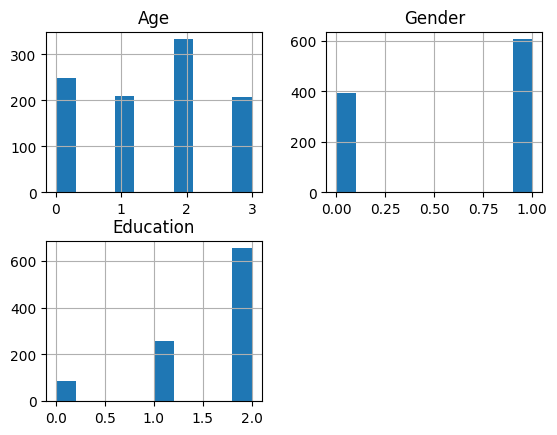

In [19]:
# visualization shows that marginal distributions of the three variables align to the priors
df.hist()